In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("models/offline_rl_model.pth", map_location=device, weights_only=False)

checkpoint['epsilon']

0.06073711254383927

In [ ]:
# with open("metrics/3/offline_rewards_130.json", "r") as f:
#     d1 = json.load(f)
# len(d1)

141

### Merging metrics over episodes

In [2]:
with open("metrics/3/offline_rewards_141.json", "r") as f:
    d1 = json.load(f)
with open("metrics/3/offline_rewards_200.json", "r") as f:
    d2 = json.load(f)
with open("metrics/3/offline_rewards_300.json", "r") as f:
    d3 = json.load(f)
with open("metrics/3/offline_rewards_400.json", "r") as f:
    d4 = json.load(f)
# with open("metrics/3/offline_rewards_400.json", "r") as f:
#     d5 = json.load(f)
    
len(d1), len(d2), len(d3), len(d4), len(d1) + len(d2) + len(d3) + len(d4)

(141, 59, 100, 100, 400)

In [3]:
d1.update(d2)
d1.update(d3)
d1.update(d4)
# d1.update(d5)
len(d1)

400

In [4]:
with open("metrics/3/offline_rewards.json", "w") as f:
    json.dump(d1, fp=f, indent=4)

In [5]:
dct = d1

### Extracting Graph

In [3]:
import matplotlib.pyplot as plt
import json

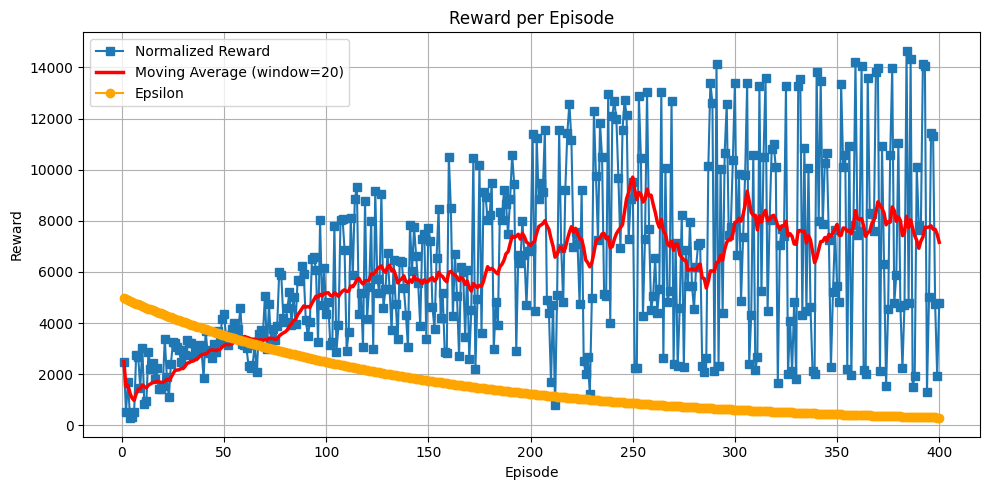

In [25]:
id = 3

with open(f"metrics/{id}/offline_rewards.json", "r") as f:
    dct = json.load(f)
    
episodes = list(range(1, len(dct) + 1))

rewards = [dct[str(e)]["reward"] for e in episodes]
rewards_normalized = [dct[str(e)]["reward"] / dct[str(e)]["population"] * 100 for e in episodes]
epsilons = [dct[str(e)]["epsilon"] * 5000 for e in episodes]

# ---- Moving average ----
window_size = 20 # you can tune this (e.g., 10, 20, 50)
moving_avg = []
for i in range(len(rewards_normalized)):
    if i < window_size:
        moving_avg.append(np.mean(rewards_normalized[:i+1]))
        # moving_avg.append(rewards_normalized[i])
    else:
        moving_avg.append(np.mean(rewards_normalized[i-window_size+1:i+1]))
# moving_avg = np.convolve(
#     rewards_normalized,
#     np.ones(window_size) / window_size,
#     mode='valid'
# )
# ma_episodes = episodes[window_size - 1:] # align x-axis

# Plot
plt.figure(figsize=(10, 5))
# plt.plot(episodes, rewards, marker='o', label='Reward')
plt.plot(episodes, rewards_normalized, marker='s', label='Normalized Reward')
plt.plot(episodes, moving_avg, linewidth=2.5, label=f'Moving Average (window={window_size})', color='red')
plt.plot(episodes, epsilons, marker='o', label="Epsilon", color="orange")

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
def plott(id, window_size=20):
    with open(f"metrics/{id}/offline_rewards.json", "r") as f:
        dct = json.load(f)
    episodes = list(range(1, len(dct) + 1))
    # rewards = [dct[str(e)]["reward"] for e in episodes]
    rewards_normalized = [dct[str(e)]["reward"] / dct[str(e)]["population"] * 100 for e in episodes]
    epsilons = [dct[str(e)]["epsilon"] * 5000 for e in episodes]

    window_size = window_size
    moving_avg = []
    for i in range(len(rewards_normalized)):
        if i < window_size:
            moving_avg.append(np.mean(rewards_normalized[:i+1]))
        else:
            moving_avg.append(np.mean(rewards_normalized[i-window_size+1:i+1]))
    # Plot
    plt.figure(figsize=(10, 5))
    # plt.plot(episodes, rewards, marker='o', label='Reward')
    plt.plot(episodes, rewards_normalized, marker='s', label='Normalized Reward per 100 users')
    plt.plot(episodes, moving_avg, linewidth=2.5, label=f'Moving Average (window={window_size})', color='red')
    # plt.plot(episodes, epsilons, marker='o', label="Epsilon", color="orange")
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Reward per Episode')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

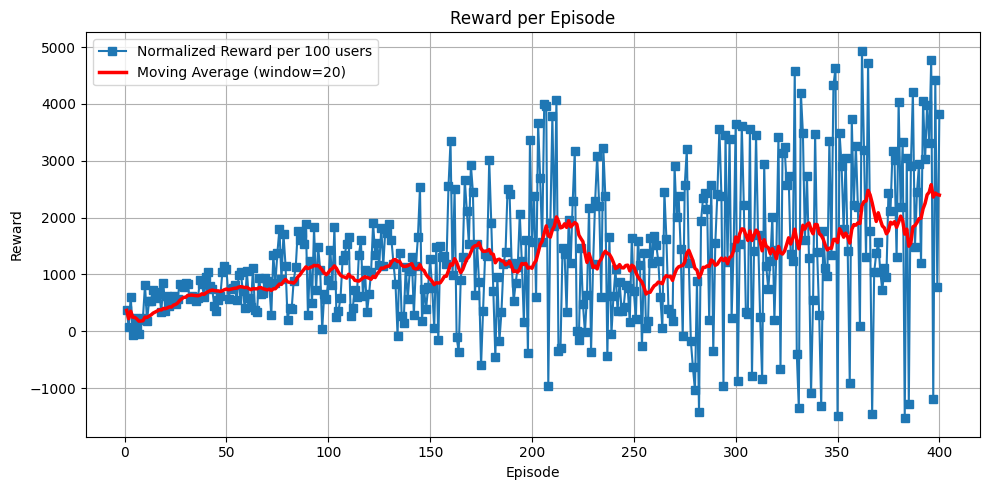

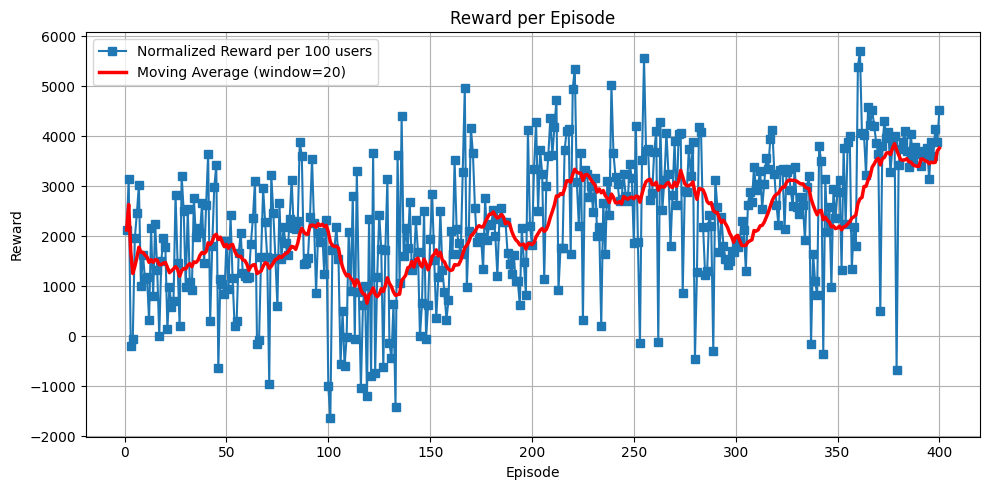

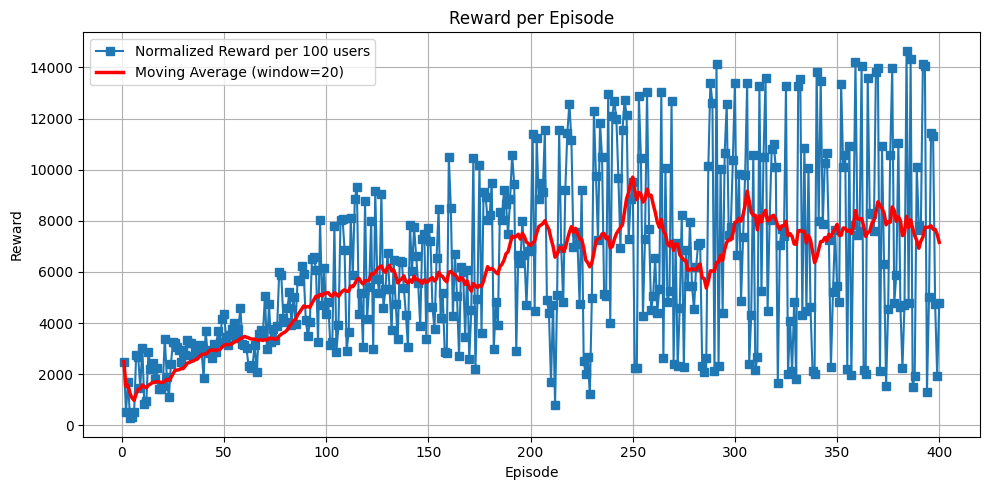

In [31]:
plott(1)
plott(2)
plott(3)

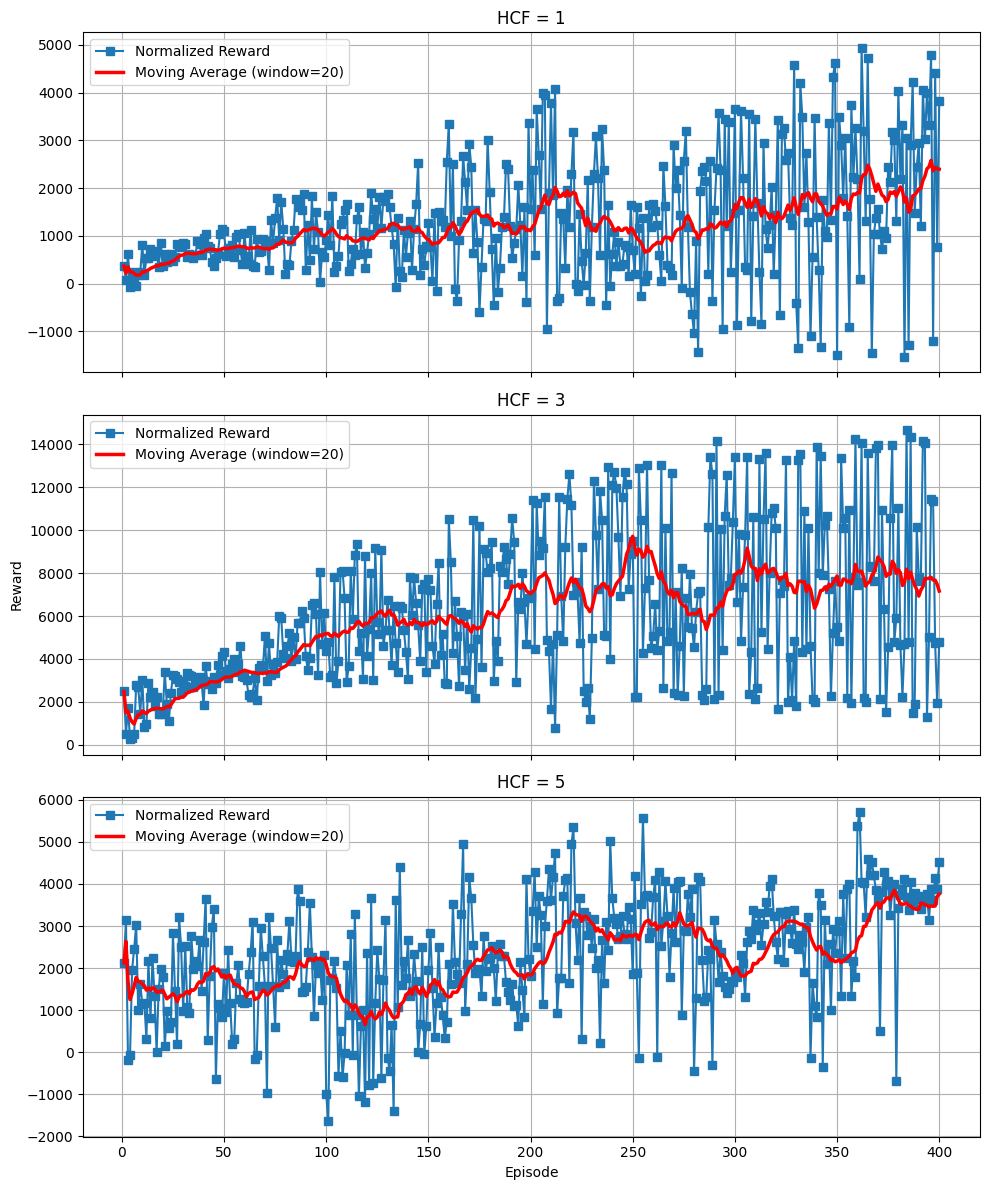

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# -------- Plot 1 --------
id = 1
with open(f"metrics/{id}/offline_rewards.json", "r") as f:
    dct = json.load(f)
episodes = list(range(1, len(dct) + 1))
rewards = [dct[str(e)]["reward"] for e in episodes]
rewards_normalized = [dct[str(e)]["reward"] / dct[str(e)]["population"] * 100 for e in episodes]
epsilons = [dct[str(e)]["epsilon"] * 5000 for e in episodes]
# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(rewards_normalized)):
    if i < window_size:
        moving_avg.append(np.mean(rewards_normalized[:i+1]))
    else:
        moving_avg.append(np.mean(rewards_normalized[i-window_size+1:i+1]))

axes[0].plot(episodes, rewards_normalized, marker='s', label='Normalized Reward')
axes[0].plot(episodes, moving_avg, linewidth=2.5, label=f'Moving Average (window={window_size})', color='red')
axes[0].set_title("HCF = 1")
axes[0].legend()
axes[0].grid(True)
# axes[0].tight_layout()
# axes[0].show()


# -------- Plot 2 --------
id = 3
with open(f"metrics/{id}/offline_rewards.json", "r") as f:
    dct = json.load(f)
episodes = list(range(1, len(dct) + 1))
rewards = [dct[str(e)]["reward"] for e in episodes]
rewards_normalized = [dct[str(e)]["reward"] / dct[str(e)]["population"] * 100 for e in episodes]
epsilons = [dct[str(e)]["epsilon"] * 5000 for e in episodes]
# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(rewards_normalized)):
    if i < window_size:
        moving_avg.append(np.mean(rewards_normalized[:i+1]))
    else:
        moving_avg.append(np.mean(rewards_normalized[i-window_size+1:i+1]))

axes[1].plot(episodes, rewards_normalized, marker='s', label='Normalized Reward')
axes[1].plot(episodes, moving_avg, linewidth=2.5, label=f'Moving Average (window={window_size})', color='red')
# axes[1].plot(episodes, epsilons, marker='o', label="Epsilon", color="orange")
# axes[1].xlabel('Episode')
# axes[1].ylabel('Reward')
# axes[1].title('Reward per Episode')
axes[1].set_title("HCF = 3")
axes[1].legend()
axes[1].grid(True)
# axes[1].tight_layout()
# axes[1].show()



# -------- Plot 3 --------
id = 2
with open(f"metrics/{id}/offline_rewards.json", "r") as f:
    dct = json.load(f)
episodes = list(range(1, len(dct) + 1))
rewards = [dct[str(e)]["reward"] for e in episodes]
rewards_normalized = [dct[str(e)]["reward"] / dct[str(e)]["population"] * 100 for e in episodes]
epsilons = [dct[str(e)]["epsilon"] * 5000 for e in episodes]
# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(rewards_normalized)):
    if i < window_size:
        moving_avg.append(np.mean(rewards_normalized[:i+1]))
    else:
        moving_avg.append(np.mean(rewards_normalized[i-window_size+1:i+1]))

axes[2].plot(episodes, rewards_normalized, marker='s', label='Normalized Reward')
axes[2].plot(episodes, moving_avg, linewidth=2.5, label=f'Moving Average (window={window_size})', color='red')
# axes[2].plot(episodes, epsilons, marker='o', label="Epsilon", color="orange")
axes[2].set_title("HCF = 5")
axes[2].legend()
axes[2].grid(True)

axes[1].set_ylabel("Reward")
axes[2].set_xlabel("Episode")


plt.tight_layout()
plt.show()